# Same-area and fixed-extent provider acquisition checks

This notebook asks two operational questions: how coverage differs between providers over identical WGS84 bounds, and how coverage detail changes from z10 to z18 inside the same 1 km × 1 km extent. It covers all 16 implemented paths. Network access is disabled by default; validated map outputs are embedded while raw responses stay under the ignored `local/` directory.


In [1]:
import math
import os
import shutil
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as NotebookImage
from IPython.display import display
from matplotlib.colors import ListedColormap


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "coverage_acquisition").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from inside the shared-dev repository.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "integrations" / "mappls_realview" / "src"))

from mappls_realview.bbox import BBox as MapplsBBox
from mappls_realview.bbox import tiles_for_bbox as mappls_tiles_for_bbox
from mappls_realview.sdk_capture import capture_sdk_bbox_async

from coverage_acquisition.case_studies import (
    AREA_COMPARISON_CASES,
    MAPPLS_KEY,
    MULTISCALE_CASES,
    MULTISCALE_LEVELS,
    PROVIDER_LABELS,
    TENCENT_KEY,
    area_case,
    fixed_extent_bbox,
    multiscale_case,
    multiscale_plan,
    validate_case_contract,
    validate_multiscale_probe,
)
from coverage_acquisition.geo import tile_range_for_bbox
from coverage_acquisition.models import FetchAreaRequest
from coverage_acquisition.providers import PROVIDERS
from coverage_acquisition.runners import fetch_provider_coverage
from coverage_acquisition.tencent_pmtiles import (
    DEFAULT_TENCENT_PMTILES_URL,
    fetch_tencent_pmtiles_sv_coverage,
)
from coverage_acquisition.visualization import (
    load_mappls_segments,
    load_result_from_manifest,
    plot_mappls_segments,
    plot_result,
    style_geo_axis,
)

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
        "font.size": 7,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
    }
)

## Controls

Add individual `(case, provider)` or `(provider, level)` pairs only after reviewing authorization and request size. Access-gated providers also require explicit authorization below.


In [2]:
ALLOW_NETWORK = os.getenv("SVI_NOTEBOOK_ALLOW_NETWORK") == "1"
SHOW_REFERENCE_MAPS = os.getenv("SVI_SHOW_REFERENCE_MAPS") == "1"
CAPTURE_FIXED_EXTENT_MAPS = os.getenv("SVI_CAPTURE_FIXED_EXTENT_MAPS") == "1"
FORCE_FIXED_EXTENT_REFRESH = os.getenv("SVI_FORCE_FIXED_EXTENT_REFRESH") == "1"
RUN_ACQUISITIONS: set[tuple[str, str]] = set()
AUTHORIZED_ACCESS_GATED = {
    value.strip() for value in os.getenv("SVI_AUTHORIZED_ACCESS_GATED", "").split(",") if value.strip()
}
FIXED_EXTENT_PROVIDER_FILTER = {
    value.strip() for value in os.getenv("SVI_FIXED_EXTENT_PROVIDERS", "").split(",") if value.strip()
}
RENDER_CASES: tuple[str, ...] = ()

OUTPUT_ROOT = PROJECT_ROOT / "local" / "provider_comparison_cases"
FIGURE_ROOT = OUTPUT_ROOT / "figures"
REFERENCE_FIGURE_ROOT = OUTPUT_ROOT / "reference_figures"
MAPILLARY_ACCESS_TOKEN = os.getenv("MAPILLARY_ACCESS_TOKEN")
MAPPLS_CHROME_EXECUTABLE = os.getenv("MAPPLS_CHROME_EXECUTABLE")
TENCENT_PMTILES_URL = os.getenv("TENCENT_PMTILES_URL", DEFAULT_TENCENT_PMTILES_URL)

## 1. Same-area, cross-provider comparison

The case contract retains the existing bounds and source selections. Requested and effective source levels are kept separate; Kakao uses native L-level semantics.


In [3]:
validate_case_contract()
case_rows = []
for case in AREA_COMPARISON_CASES:
    for item in case.providers:
        semantics = "native L" if item.provider == "kakao" else "z"
        case_rows.append(
            {
                "case": case.key,
                "area": case.label,
                "provider": PROVIDER_LABELS[item.provider],
                "provider_key": item.provider,
                "requested_level": f"{semantics}{item.requested_level}",
                "bbox_wgs84": tuple(case.bbox.as_dict().values()),
            }
        )

case_df = pd.DataFrame(case_rows)
assert case_df["provider_key"].nunique() == 16
display(case_df)

,case,area,provider,provider_key,requested_level,bbox_wgs84
0,shenzhen_futian,Shenzhen Futian,Baidu,baidu,z18,"(114.02, 22.5, 114.08, 22.56)"
1,shenzhen_futian,Shenzhen Futian,Tencent Street View,tencent_pmtiles_sv,z12,"(114.02, 22.5, 114.08, 22.56)"
2,hong_kong_core,Hong Kong Island + Kowloon,Google Street View,svmap_google,z13,"(114.1, 22.25, 114.25, 22.35)"
3,hong_kong_core,Hong Kong Island + Kowloon,Apple Look Around,apple_lookaround,z13,"(114.1, 22.25, 114.25, 22.35)"
4,hong_kong_core,Hong Kong Island + Kowloon,Baidu,baidu,z13,"(114.1, 22.25, 114.25, 22.35)"
5,hong_kong_core,Hong Kong Island + Kowloon,Tencent Street View,tencent_pmtiles_sv,z12,"(114.1, 22.25, 114.25, 22.35)"
6,seoul_center,Central Seoul,Google Street View,svmap_google,z15,"(126.965, 37.555, 127.005, 37.585)"
7,seoul_center,Central Seoul,Naver,naver,z15,"(126.965, 37.555, 127.005, 37.585)"
8,seoul_center,Central Seoul,Kakao,kakao,native L5,"(126.965, 37.555, 127.005, 37.585)"
9,chiang_mai,Chiang Mai,Google Street View,svmap_google,z14,"(98.899549, 18.697236, 99.073957, 18.864633)"


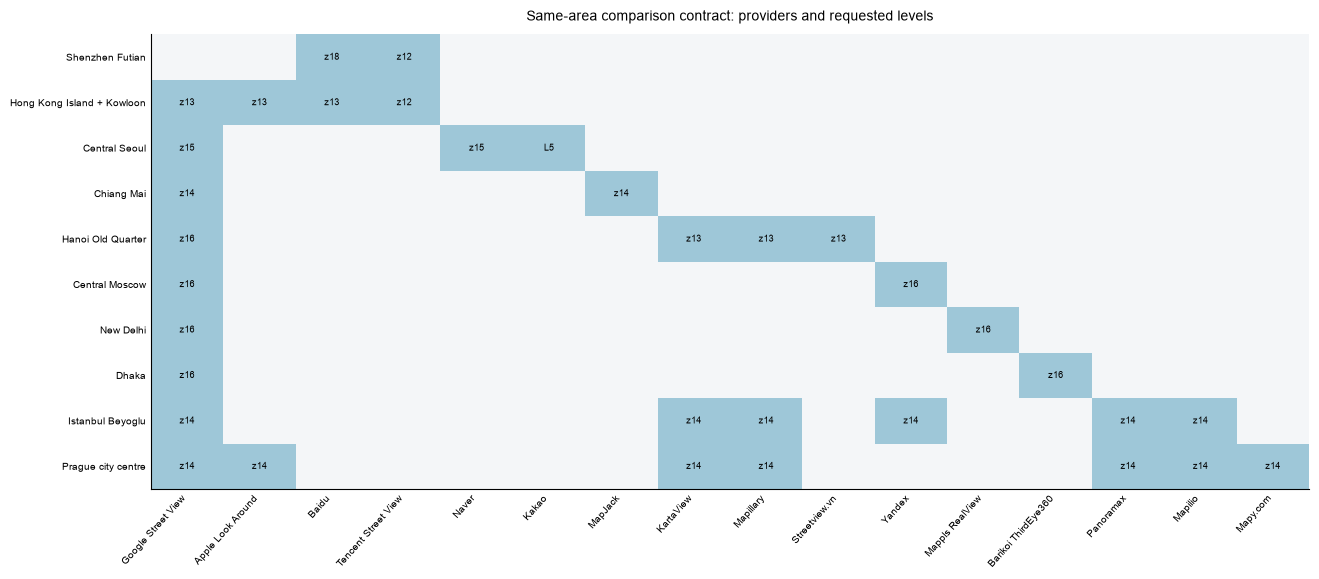

In [4]:
provider_order = [case.provider for case in MULTISCALE_CASES]
provider_index = {provider: index for index, provider in enumerate(provider_order)}
matrix = np.zeros((len(AREA_COMPARISON_CASES), len(provider_order)), dtype=int)
labels = np.full(matrix.shape, "", dtype=object)
for row_index, case in enumerate(AREA_COMPARISON_CASES):
    for item in case.providers:
        column_index = provider_index[item.provider]
        matrix[row_index, column_index] = 1
        prefix = "L" if item.provider == "kakao" else "z"
        labels[row_index, column_index] = f"{prefix}{item.requested_level}"

fig, ax = plt.subplots(figsize=(13.2, 5.8))
ax.imshow(matrix, cmap=ListedColormap(["#F4F6F8", "#9EC7D8"]), vmin=0, vmax=1, aspect="auto")
for row_index in range(matrix.shape[0]):
    for column_index in range(matrix.shape[1]):
        if labels[row_index, column_index]:
            ax.text(column_index, row_index, labels[row_index, column_index], ha="center", va="center", fontsize=6.2)
ax.set_xticks(range(len(provider_order)), [PROVIDER_LABELS[key] for key in provider_order], rotation=48, ha="right")
ax.set_yticks(range(len(AREA_COMPARISON_CASES)), [case.label for case in AREA_COMPARISON_CASES])
ax.set_title("Same-area comparison contract: providers and requested levels", fontsize=10, pad=10)
ax.tick_params(length=0)
fig.tight_layout()
plt.show()

In [5]:
def plan_area_request(case, item):
    if item.provider in PROVIDERS:
        result = fetch_provider_coverage(
            FetchAreaRequest(
                provider=item.provider,
                bbox=case.bbox,
                output_root=OUTPUT_ROOT,
                display_zoom=item.requested_level,
                dry_run=True,
            )
        )
        job = result["jobs"][0]
        return {
            "case": case.key,
            "provider": item.provider,
            "requested_level": item.requested_level,
            "effective_source_level": job["source_zoom"],
            "source_id": job["source"].id,
            "source_kind": job["source"].kind,
            "planned_tiles": job["source_tile_count"],
            "plan_status": "dry_run",
        }
    if item.provider == TENCENT_KEY:
        tile_range = tile_range_for_bbox(case.bbox, item.requested_level, "web_mercator")
        return {
            "case": case.key,
            "provider": item.provider,
            "requested_level": item.requested_level,
            "effective_source_level": item.requested_level,
            "source_id": "qq_map_lines_pmtiles_sv",
            "source_kind": "vector_mvt",
            "planned_tiles": tile_range.count,
            "plan_status": "archive_plan",
        }
    west, south, east, north = case.bbox.as_dict().values()
    count = len(mappls_tiles_for_bbox(MapplsBBox(west, south, east, north), item.requested_level))
    return {
        "case": case.key,
        "provider": item.provider,
        "requested_level": item.requested_level,
        "effective_source_level": item.requested_level,
        "source_id": "mappls_realview_sdk",
        "source_kind": "vector_mvt",
        "planned_tiles": count,
        "plan_status": "access_gated",
    }


area_plan_df = pd.DataFrame(
    [plan_area_request(case, item) for case in AREA_COMPARISON_CASES for item in case.providers]
)
display(area_plan_df)

,case,provider,requested_level,effective_source_level,source_id,source_kind,planned_tiles,plan_status
0,shenzhen_futian,baidu,18,18,baidu_mapsv_tile,raster,783,dry_run
1,shenzhen_futian,tencent_pmtiles_sv,12,12,qq_map_lines_pmtiles_sv,vector_mvt,2,archive_plan
2,hong_kong_core,svmap_google,13,13,svmap_google_mts,raster,12,dry_run
3,hong_kong_core,apple_lookaround,13,13,apple_lookaround_cached_bluelines,vector_mvt,12,dry_run
4,hong_kong_core,baidu,13,13,baidu_mapsv_tile,raster,6,dry_run
5,hong_kong_core,tencent_pmtiles_sv,12,12,qq_map_lines_pmtiles_sv,vector_mvt,4,archive_plan
6,seoul_center,svmap_google,15,15,svmap_google_mts,raster,20,dry_run
7,seoul_center,naver,15,15,naver_streetview_overlay_png,raster,20,dry_run
8,seoul_center,kakao,5,5,kakao_roadviewline,raster,20,dry_run
9,chiang_mai,svmap_google,14,14,svmap_google_mts,raster,72,dry_run


In [6]:
def provider_level_for_case(case_key: str, provider_key: str):
    case = area_case(case_key)
    for item in case.providers:
        if item.provider == provider_key:
            return case, item
    raise KeyError(f"{provider_key} is not configured for {case_key}")


async def acquire_area_case(case_key: str, provider_key: str):
    if not ALLOW_NETWORK:
        raise RuntimeError("Set ALLOW_NETWORK=True before running an acquisition.")
    case, item = provider_level_for_case(case_key, provider_key)
    if provider_key in {"apple_lookaround", MAPPLS_KEY} and provider_key not in AUTHORIZED_ACCESS_GATED:
        raise PermissionError(f"Add {provider_key!r} to AUTHORIZED_ACCESS_GATED after authorization review.")
    run_label = f"{case.key}_{provider_key}"
    if provider_key in PROVIDERS:
        if provider_key == "mapillary" and not MAPILLARY_ACCESS_TOKEN:
            raise RuntimeError("Set MAPILLARY_ACCESS_TOKEN in the environment.")
        return fetch_provider_coverage(
            FetchAreaRequest(
                provider=provider_key,
                bbox=case.bbox,
                output_root=OUTPUT_ROOT,
                display_zoom=item.requested_level,
                stop_on_error=False,
                timeout_seconds=30,
                run_label=run_label,
                access_token=MAPILLARY_ACCESS_TOKEN if provider_key == "mapillary" else None,
            )
        )
    if provider_key == TENCENT_KEY:
        return fetch_tencent_pmtiles_sv_coverage(
            case.bbox,
            output_root=OUTPUT_ROOT,
            cache_dir=OUTPUT_ROOT / "tencent_pmtiles_cache",
            source_url=TENCENT_PMTILES_URL,
            source_zoom=item.requested_level,
            run_label=f"{run_label}_subbox_00",
        )
    bbox = MapplsBBox(case.bbox.min_lon, case.bbox.min_lat, case.bbox.max_lon, case.bbox.max_lat)
    return await capture_sdk_bbox_async(
        web_dir=PROJECT_ROOT / "integrations" / "mappls_realview" / "web",
        bbox=bbox,
        zoom=item.requested_level,
        out_dir=OUTPUT_ROOT / "mappls_realview",
        output_mode="production",
        run_id=f"{case.key}_mappls_z{item.requested_level}",
        headless=True,
    )


live_area_results = {}
for case_key, provider_key in sorted(RUN_ACQUISITIONS):
    live_area_results[(case_key, provider_key)] = await acquire_area_case(case_key, provider_key)
print(f"Live area acquisitions executed: {len(live_area_results)}")

Live area acquisitions executed: 0


In [7]:
def registry_manifest_path(case, provider_key):
    namespace = PROVIDERS[provider_key].output_namespace
    return OUTPUT_ROOT / namespace / f"{case.key}_{provider_key}_subbox_00" / "manifest.json"


def tencent_manifest_path(case):
    return OUTPUT_ROOT / TENCENT_KEY / f"{case.key}_{TENCENT_KEY}_subbox_00" / "manifest.json"


def mappls_summary_path(case, level):
    return OUTPUT_ROOT / "mappls_realview" / "production" / "runs" / f"{case.key}_mappls_z{level}.json"


def render_area_comparison(case_key: str):
    case = area_case(case_key)
    ncols = min(4, len(case.providers))
    nrows = math.ceil(len(case.providers) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.0 * nrows), squeeze=False)
    for ax, item in zip(axes.flat, case.providers):
        prefix = "L" if item.provider == "kakao" else "z"
        level_label = f"requested {prefix}{item.requested_level}"
        try:
            if item.provider in PROVIDERS:
                path = registry_manifest_path(case, item.provider)
                if not path.exists():
                    raise FileNotFoundError(path)
                plot_result(
                    ax,
                    load_result_from_manifest(path),
                    bbox=case.bbox,
                    label=PROVIDER_LABELS[item.provider],
                    level_label=level_label,
                )
            elif item.provider == TENCENT_KEY:
                path = tencent_manifest_path(case)
                if not path.exists():
                    raise FileNotFoundError(path)
                plot_result(
                    ax,
                    load_result_from_manifest(path),
                    bbox=case.bbox,
                    label=PROVIDER_LABELS[item.provider],
                    level_label=level_label,
                )
            else:
                path = mappls_summary_path(case, item.requested_level)
                if not path.exists():
                    raise FileNotFoundError(path)
                returned_bbox, segments = load_mappls_segments(path)
                if returned_bbox.as_dict() != case.bbox.as_dict():
                    raise RuntimeError("Mappls returned different bounds.")
                plot_mappls_segments(
                    ax,
                    segments,
                    bbox=case.bbox,
                    label=PROVIDER_LABELS[item.provider],
                    level_label=level_label,
                )
        except FileNotFoundError:
            style_geo_axis(ax, case.bbox, f"{PROVIDER_LABELS[item.provider]}\n{level_label}; not acquired")
            ax.text(0.5, 0.5, "not acquired", transform=ax.transAxes, ha="center", va="center", color="#7A8793")
    for ax in axes.flat[len(case.providers) :]:
        ax.axis("off")
    fig.suptitle(f"{case.label}: provider coverage over identical WGS84 bounds", fontsize=10, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    return fig


for case_key in RENDER_CASES:
    render_area_comparison(case_key)
    plt.show()
if not RENDER_CASES:
    print("No map panels rendered. Add a case key to RENDER_CASES after acquisition or cache review.")

No map panels rendered. Add a case key to RENDER_CASES after acquisition or cache review.


### Validated same-area map outputs

The rendered outputs below retain the actual provider coverage maps from the validated comparison run. They are embedded in this notebook for collaborators; raw tiles are intentionally excluded from the repository.


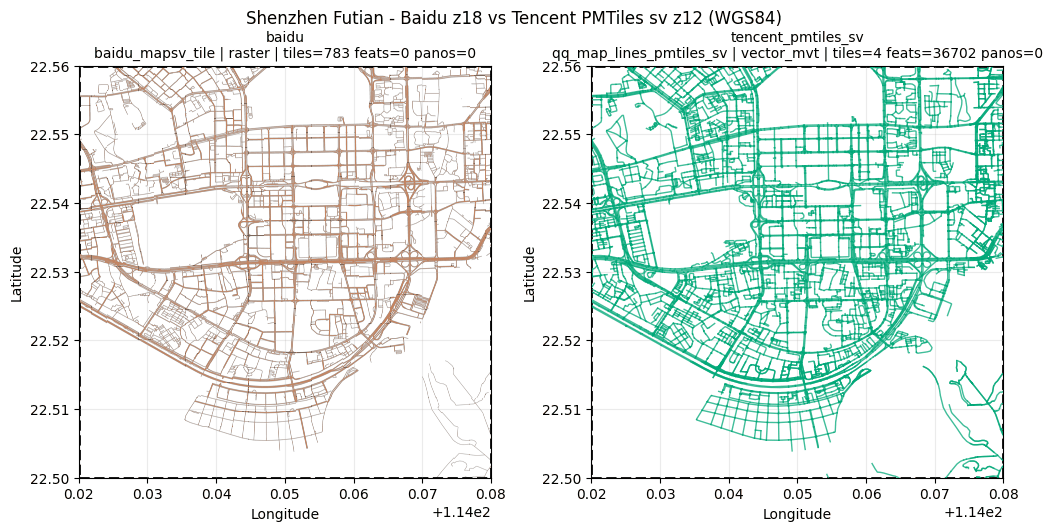

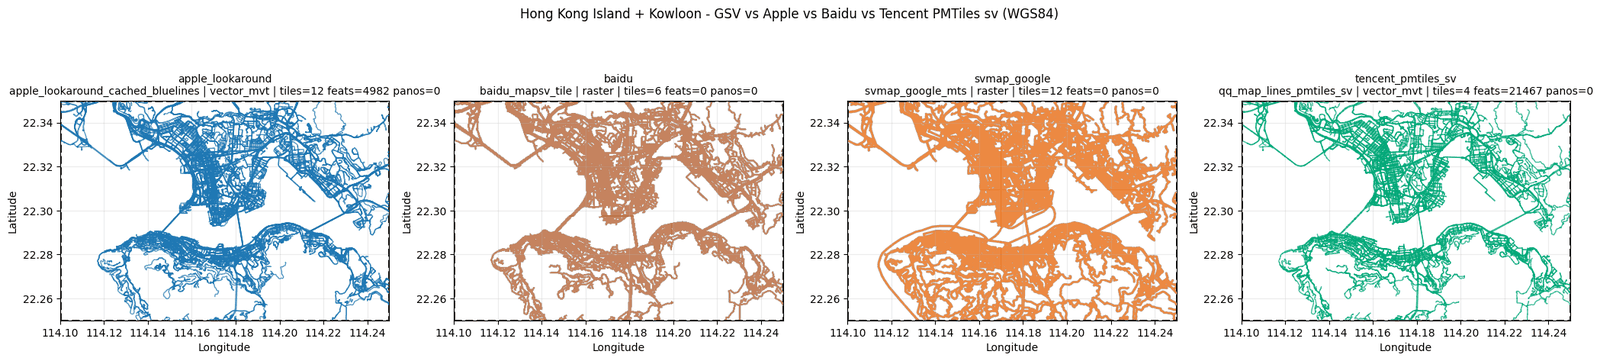

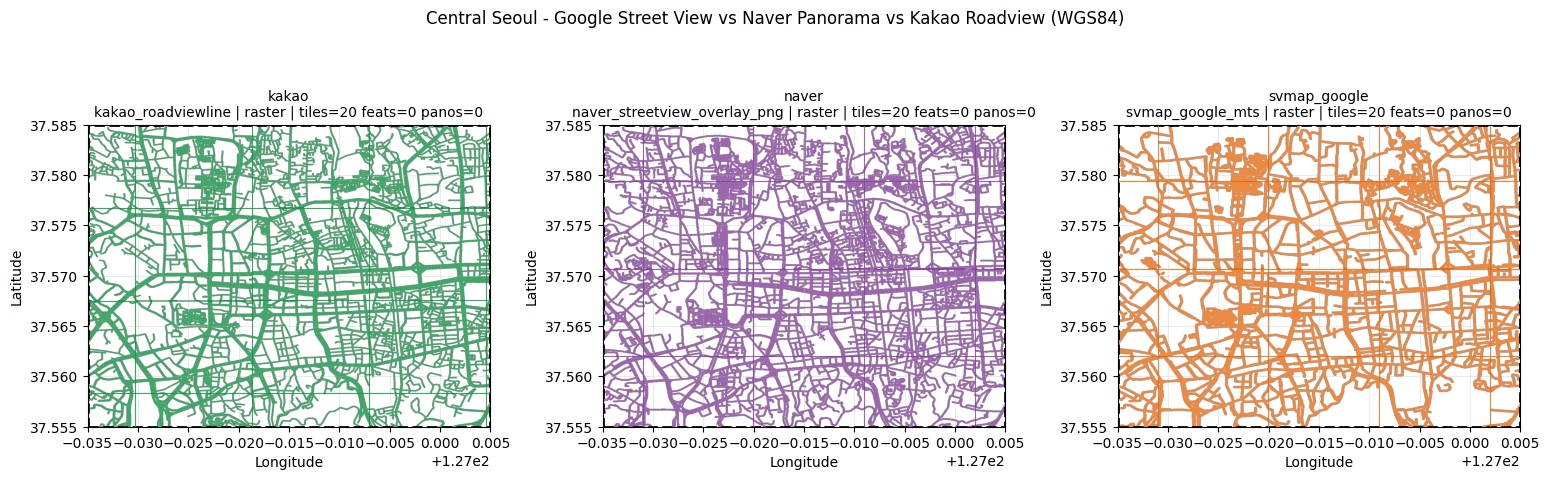

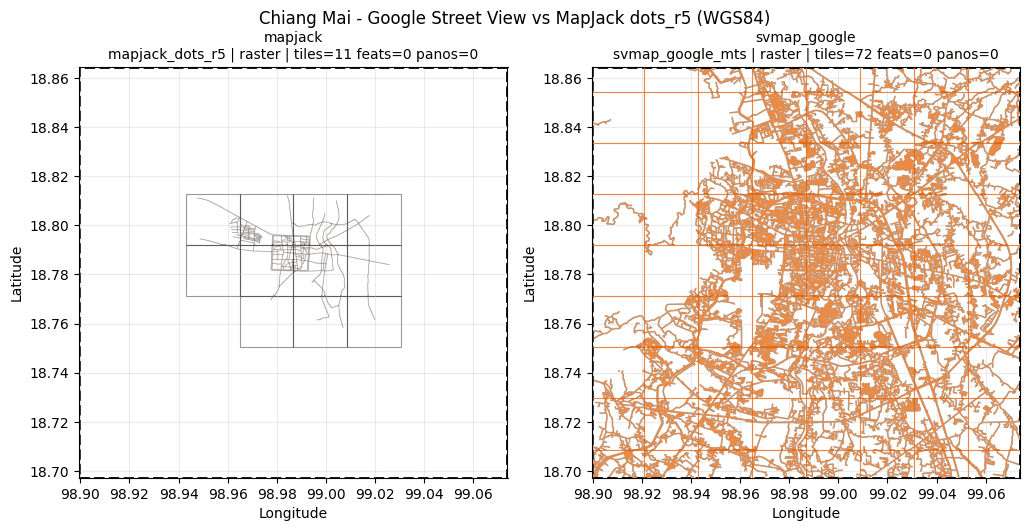

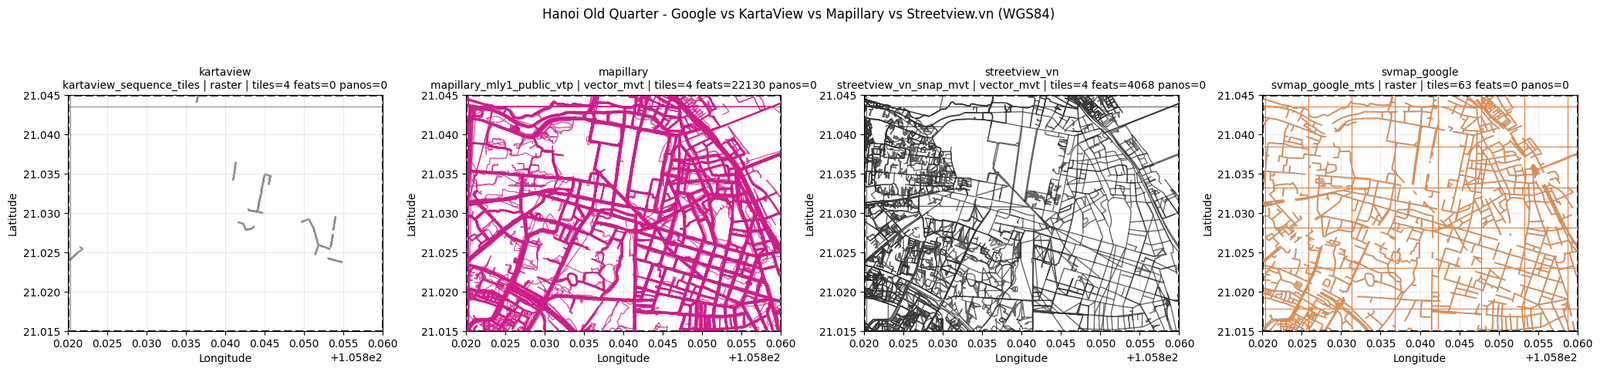

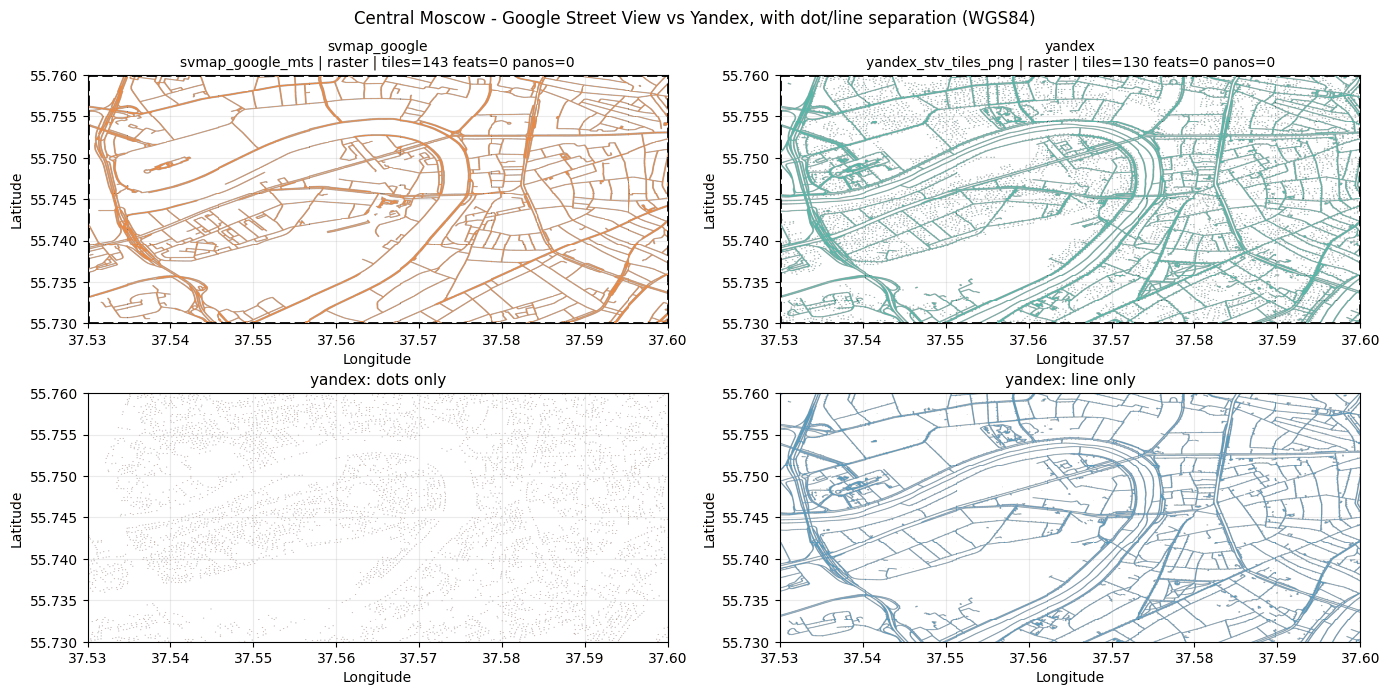

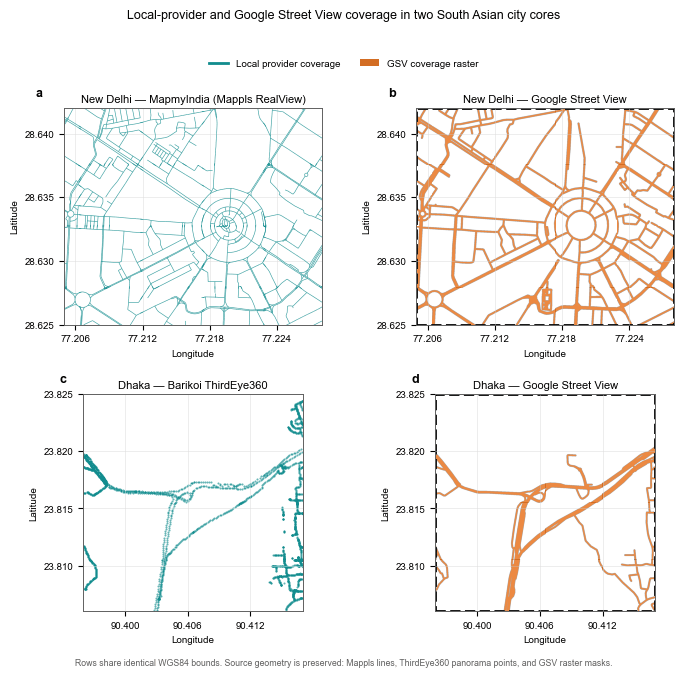

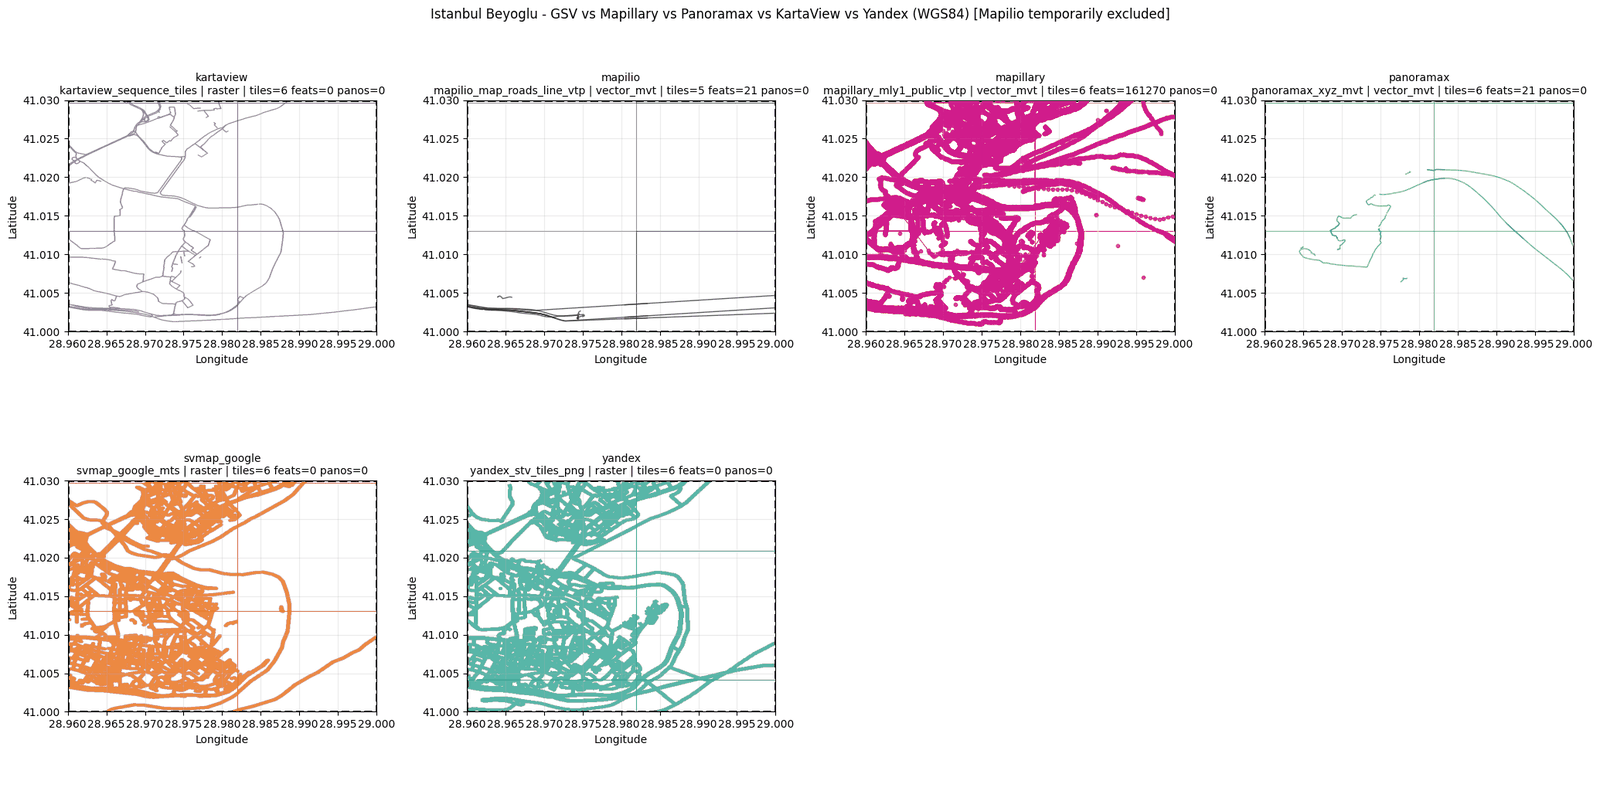

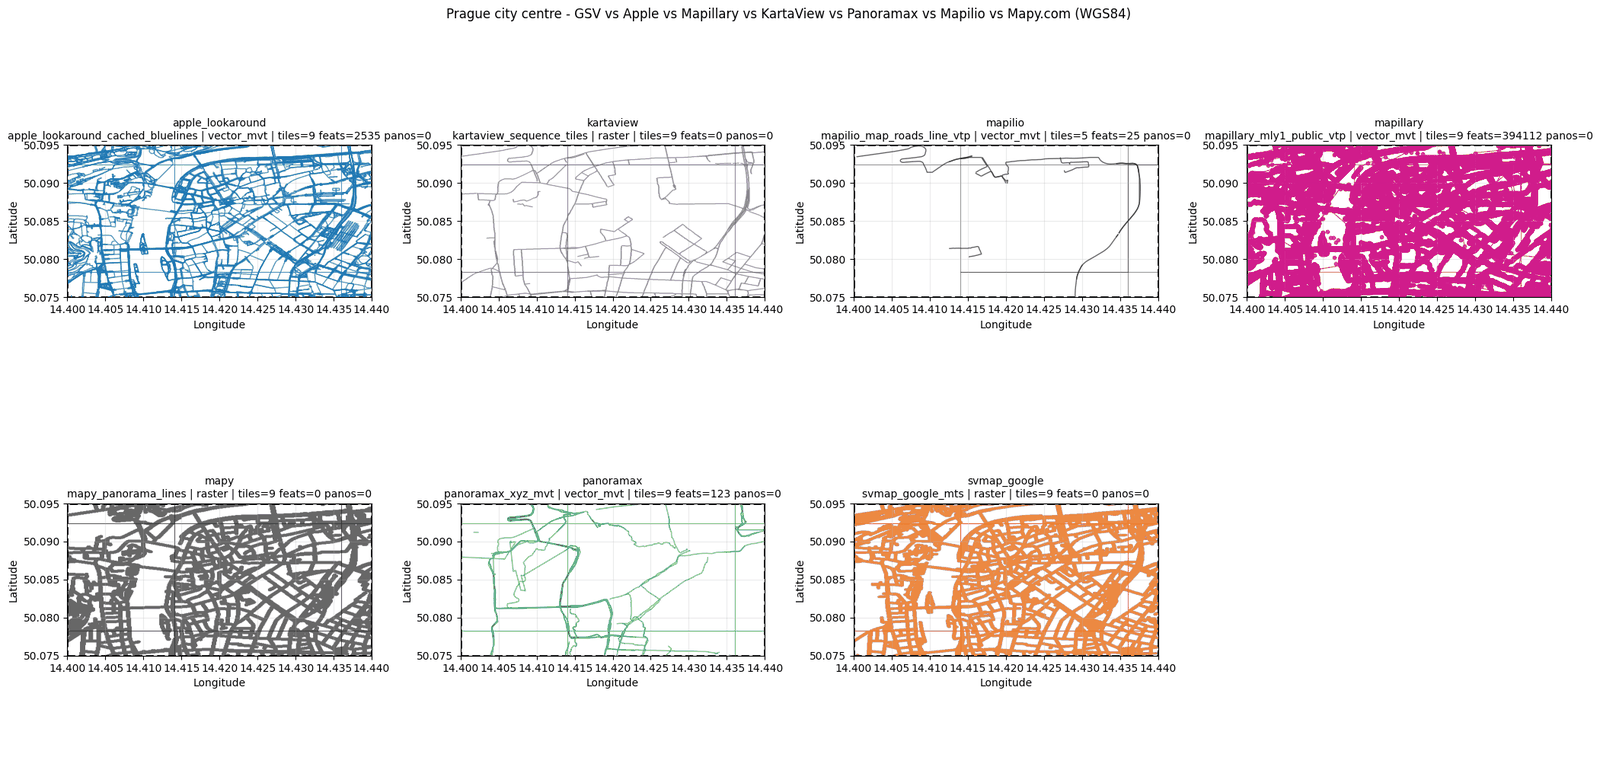

In [8]:
area_reference_paths = sorted(REFERENCE_FIGURE_ROOT.glob("area_*.png"))
if SHOW_REFERENCE_MAPS and area_reference_paths:
    for path in area_reference_paths:
        display(NotebookImage(filename=str(path)))
else:
    print(f"Embedded validated area-map plates: {len(area_reference_paths)} staged for this execution.")

## 2. Same-provider, fixed-extent comparison

Each provider retains its validated centre, but every z10–z18 panel is clipped to the same projected 1 km × 1 km square. This replaces the earlier single-native-tile comparison, whose geographic extent changed with zoom. No quantitative score is calculated here; the plates are a direct visual check of coverage detail.


In [9]:
zoom_plan_df = pd.DataFrame(multiscale_plan())
provider_order = [case.provider for case in MULTISCALE_CASES]
fixed_extent_bboxes = {case.provider: fixed_extent_bbox(case) for case in MULTISCALE_CASES}
assert MULTISCALE_LEVELS == tuple(range(10, 19))
assert len(zoom_plan_df) == 16 * 9

### Acquisition and cleanup behaviour

The reference build processes one provider and one zoom at a time. It renders the returned coverage inside the fixed square, saves the compact 3 × 3 plate, and then deletes that zoom's raw response directory. Unsupported or inaccessible levels are labelled explicitly and are not interpreted as absent coverage.


In [10]:
async def acquire_fixed_extent(provider_key: str, requested_level: int):
    plan = validate_multiscale_probe(provider_key, requested_level)
    if not ALLOW_NETWORK:
        raise RuntimeError("Set SVI_NOTEBOOK_ALLOW_NETWORK=1 before building fixed-extent maps.")
    if provider_key in {"apple_lookaround", MAPPLS_KEY} and provider_key not in AUTHORIZED_ACCESS_GATED:
        raise PermissionError(f"Authorize {provider_key!r} through SVI_AUTHORIZED_ACCESS_GATED.")
    bbox = fixed_extent_bboxes[provider_key]
    run_label = f"fixed_extent_{provider_key}_z{requested_level}"
    ephemeral_root = OUTPUT_ROOT / "ephemeral" / provider_key / f"z{requested_level}"
    if provider_key in PROVIDERS:
        if provider_key == "mapillary" and not MAPILLARY_ACCESS_TOKEN:
            raise RuntimeError("Set MAPILLARY_ACCESS_TOKEN in the environment.")
        batch = fetch_provider_coverage(
            FetchAreaRequest(
                provider=provider_key,
                bbox=bbox,
                output_root=ephemeral_root,
                display_zoom=requested_level,
                stop_on_error=False,
                timeout_seconds=180 if provider_key == "barikoi" else (10 if provider_key == "yandex" else 30),
                run_label=run_label,
                access_token=MAPILLARY_ACCESS_TOKEN if provider_key == "mapillary" else None,
            )
        )
        return {"kind": "registry", "result": batch["results"][0], "cleanup_root": ephemeral_root}
    if provider_key == TENCENT_KEY:
        batch = fetch_tencent_pmtiles_sv_coverage(
            bbox,
            output_root=ephemeral_root,
            cache_dir=ephemeral_root / "cache",
            source_url=TENCENT_PMTILES_URL,
            source_zoom=int(plan["effective_source_level"]),
            run_label=f"{run_label}_subbox_00",
        )
        return {"kind": "registry", "result": batch["results"][0], "cleanup_root": ephemeral_root}
    sdk_bbox = MapplsBBox(bbox.min_lon, bbox.min_lat, bbox.max_lon, bbox.max_lat)
    result = await capture_sdk_bbox_async(
        web_dir=PROJECT_ROOT / "integrations" / "mappls_realview" / "web",
        bbox=sdk_bbox,
        zoom=requested_level,
        out_dir=ephemeral_root,
        output_mode="production",
        run_id=run_label,
        headless=True,
        chrome_executable=MAPPLS_CHROME_EXECUTABLE,
    )
    return {"kind": "mappls", "result": result, "cleanup_root": ephemeral_root}

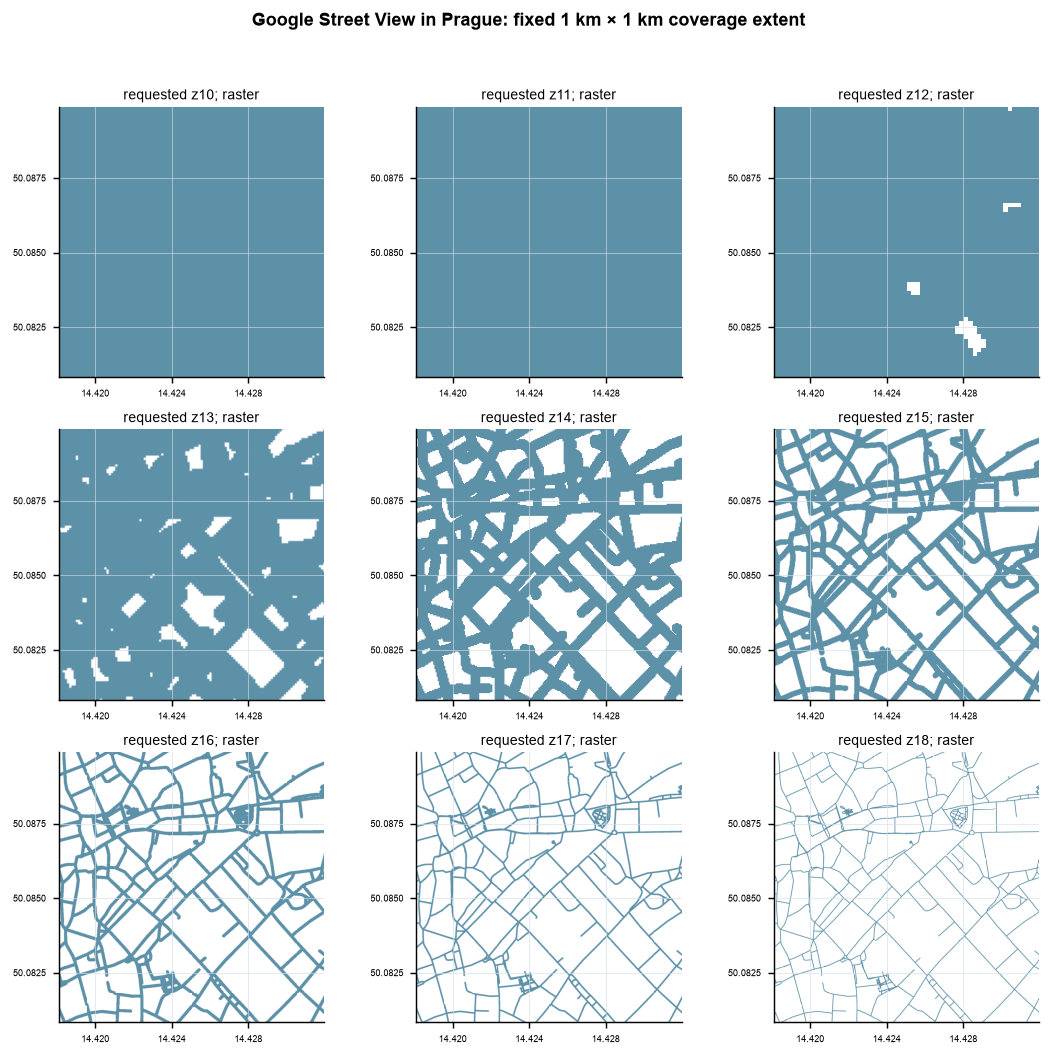

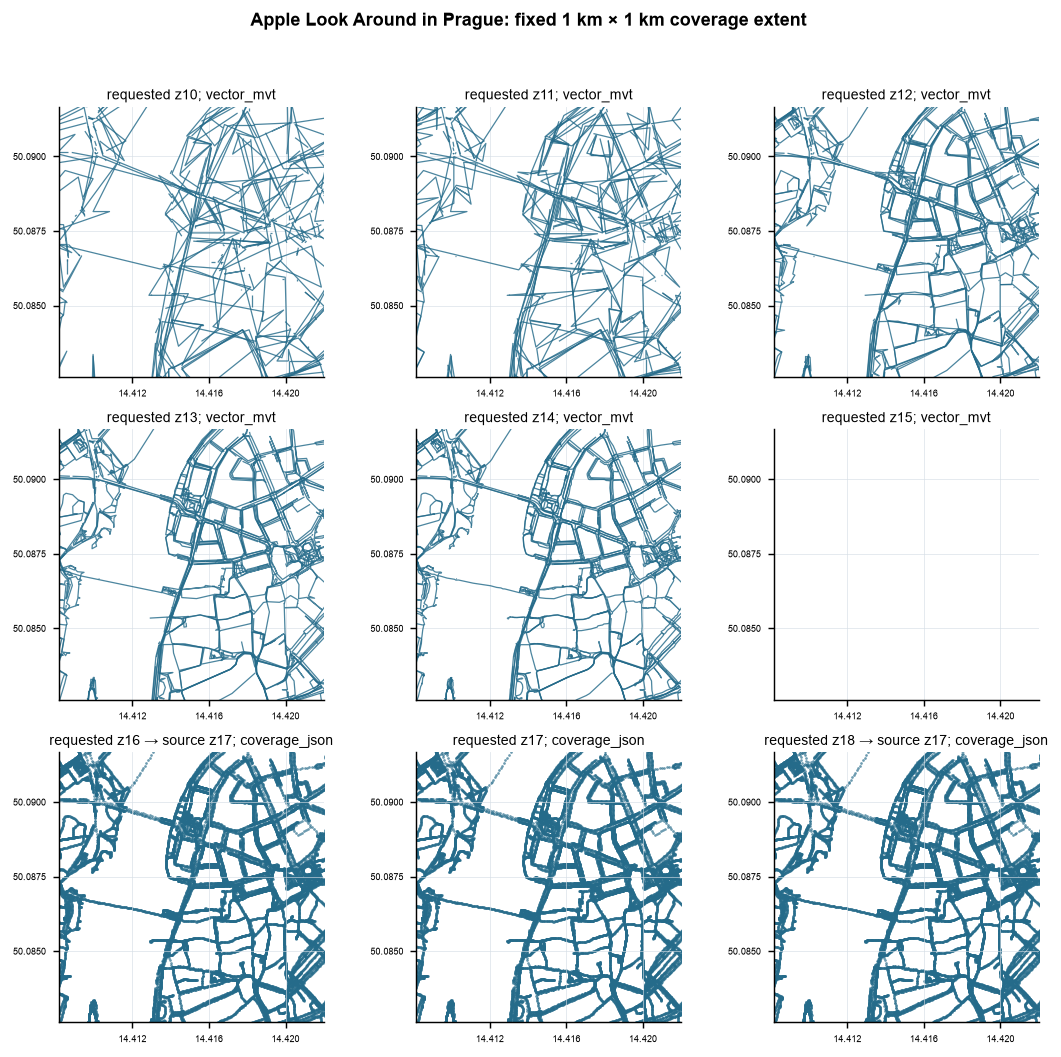

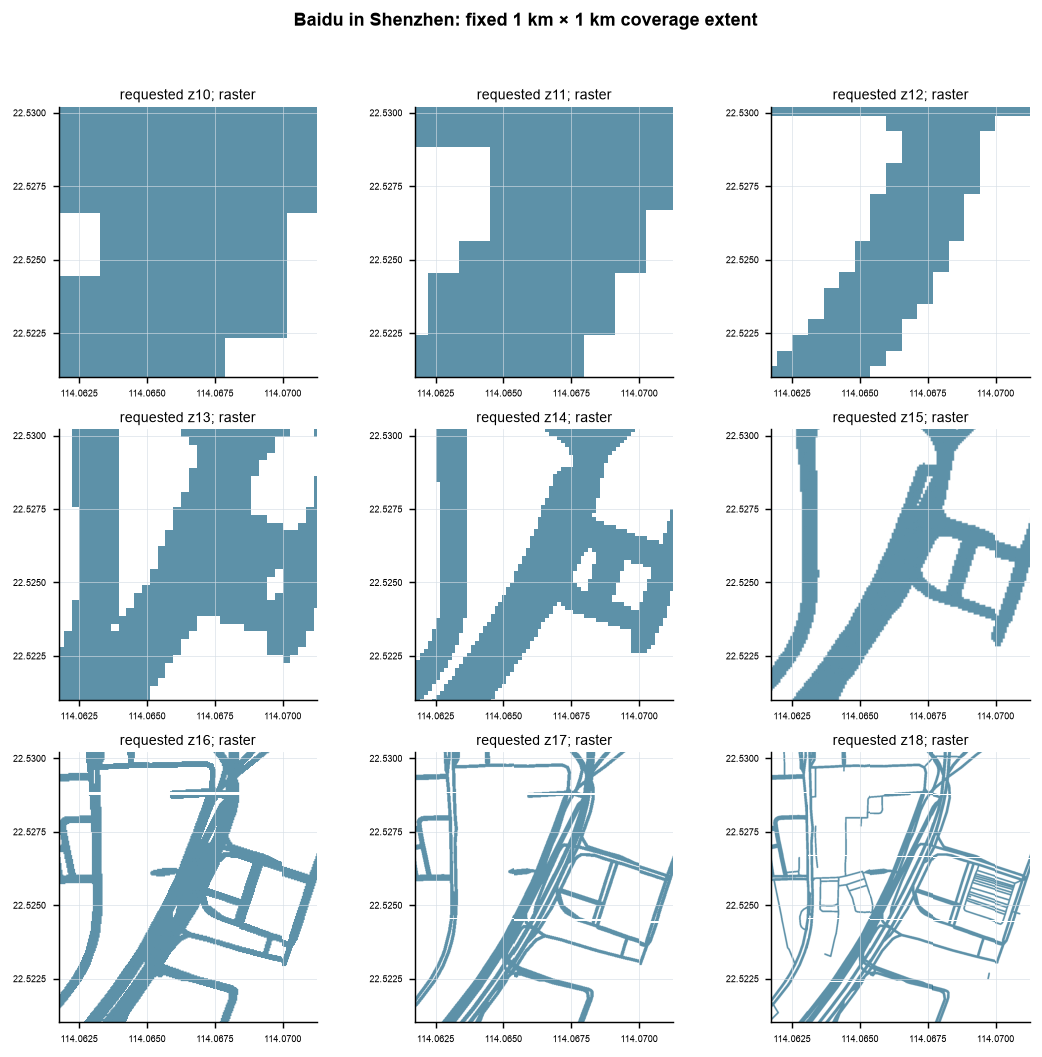

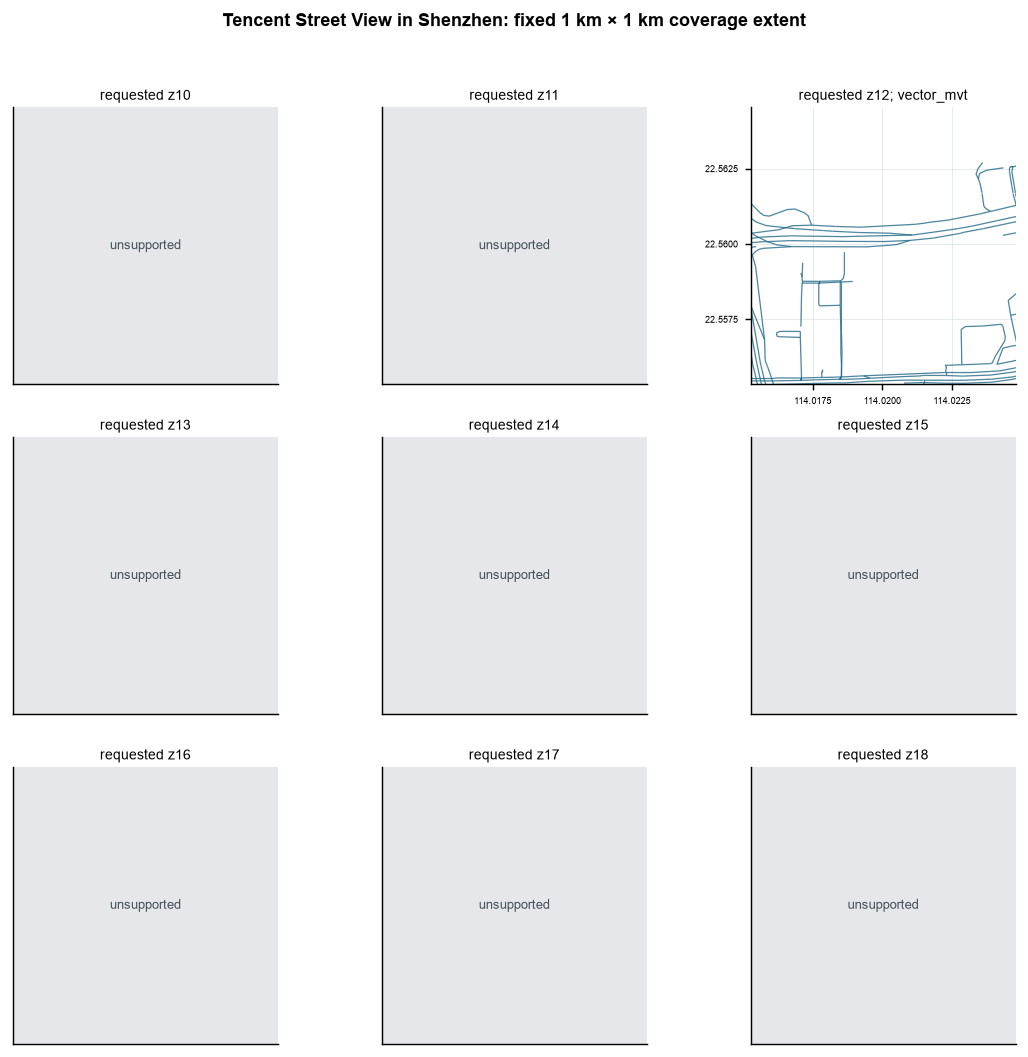

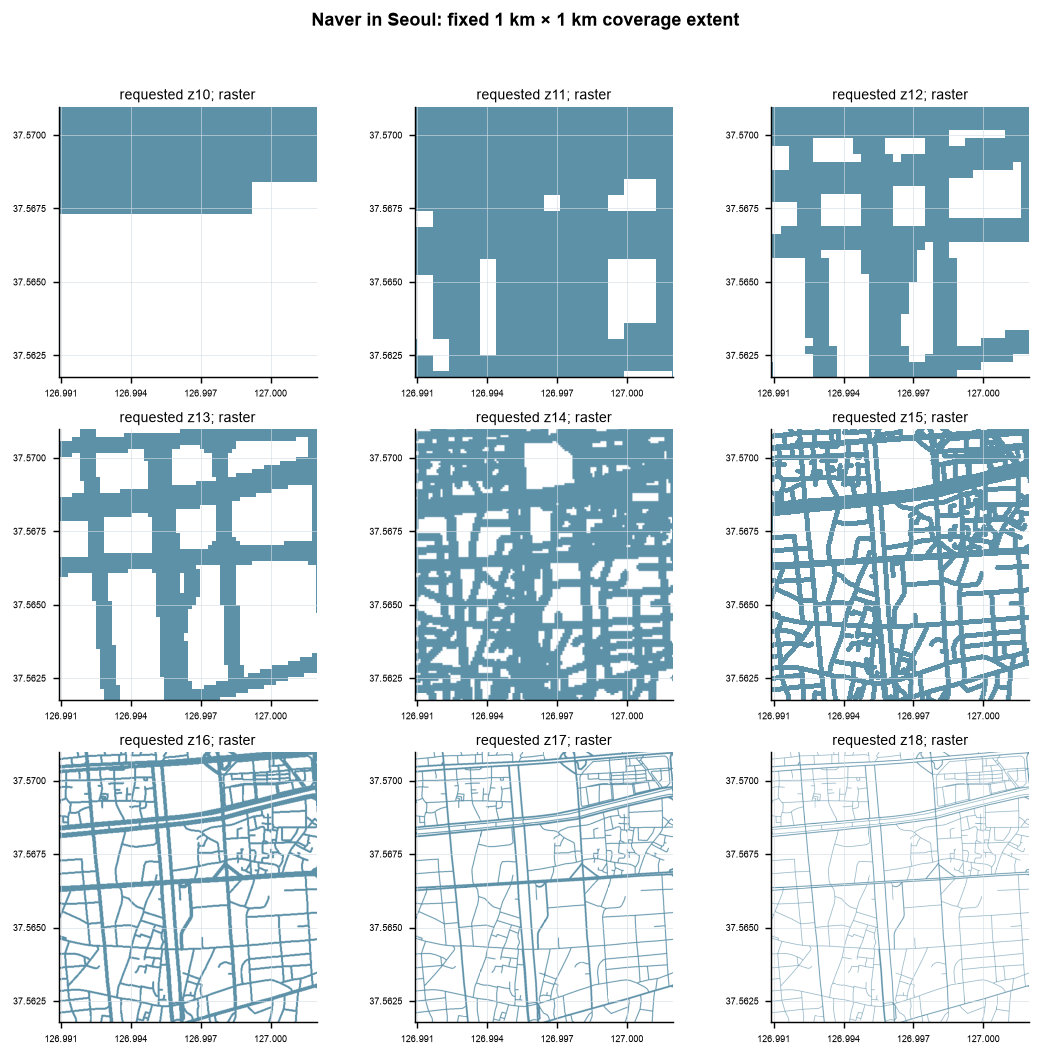

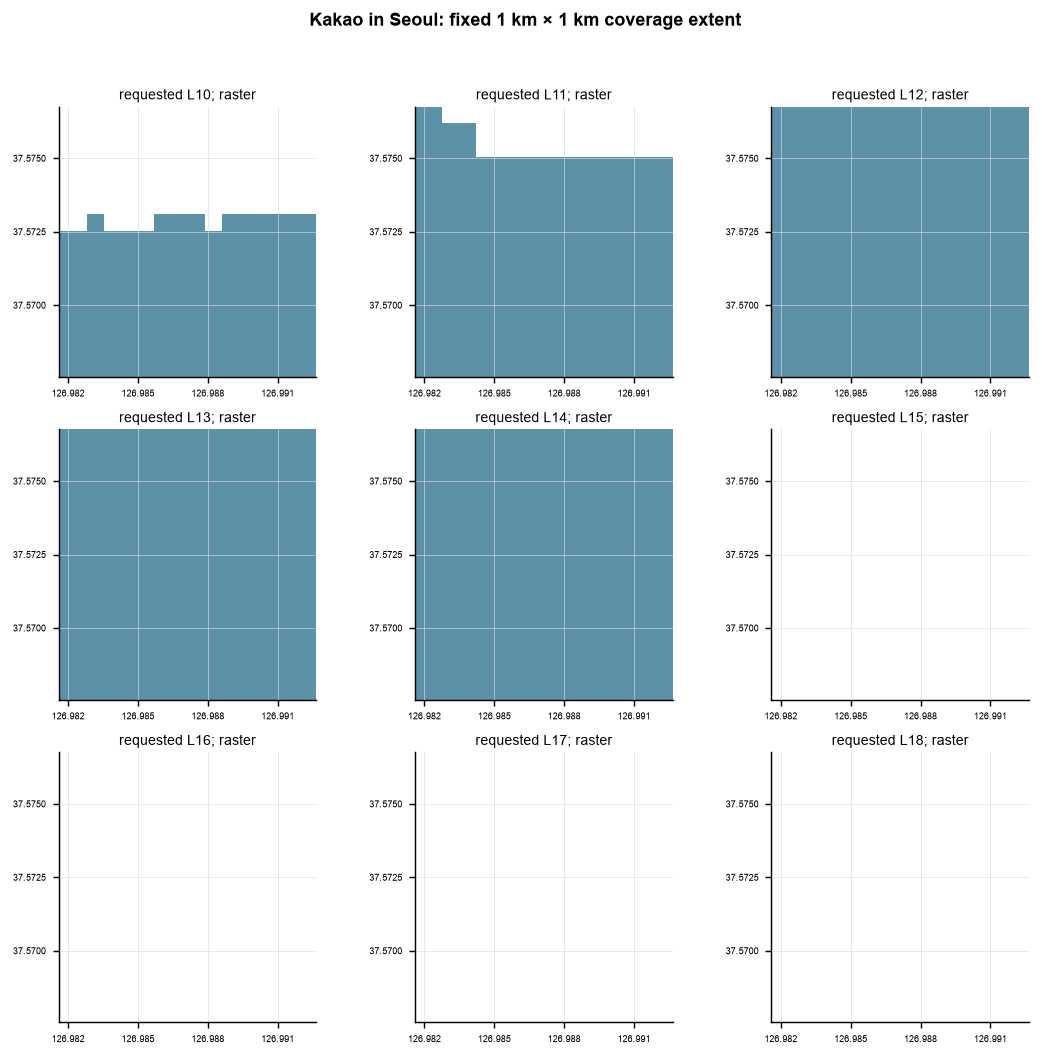

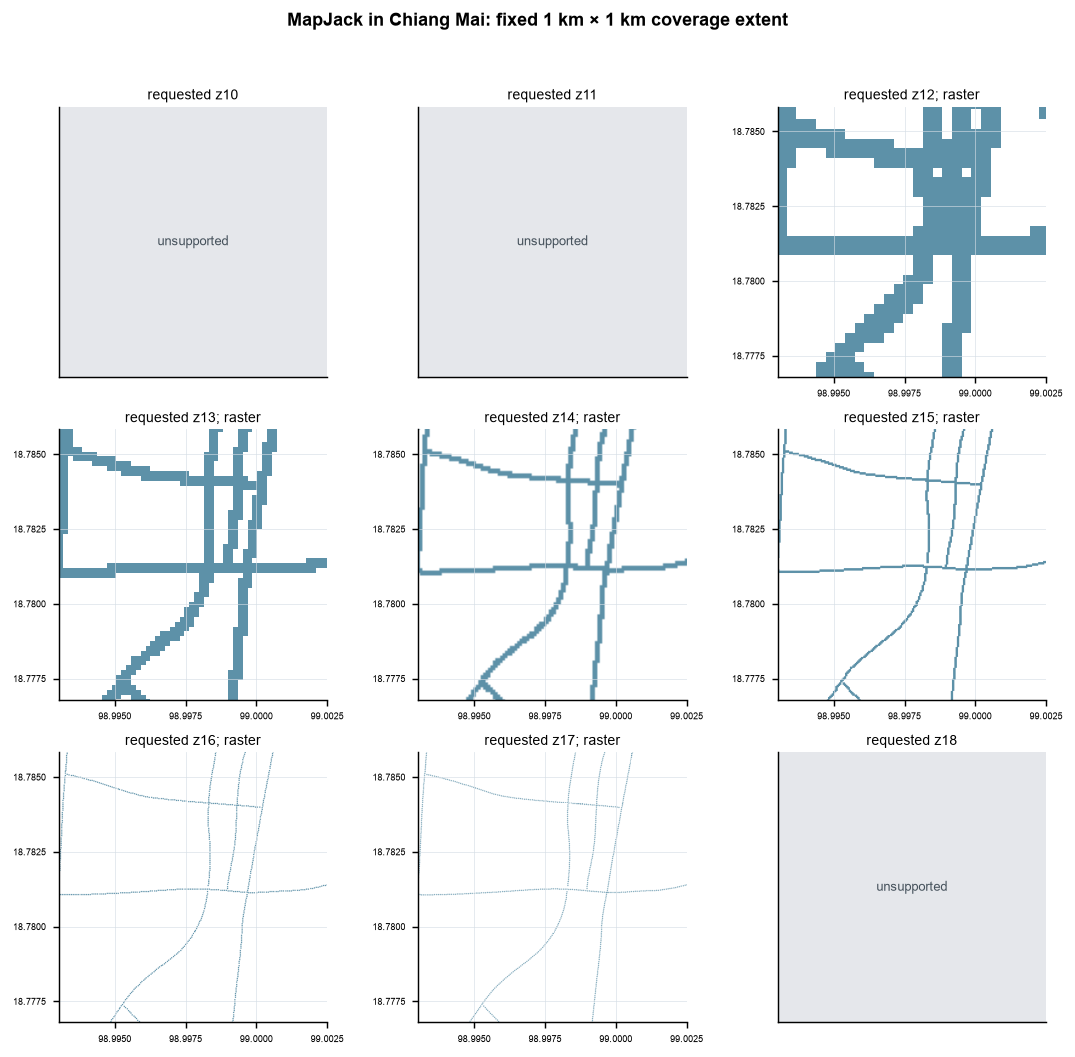

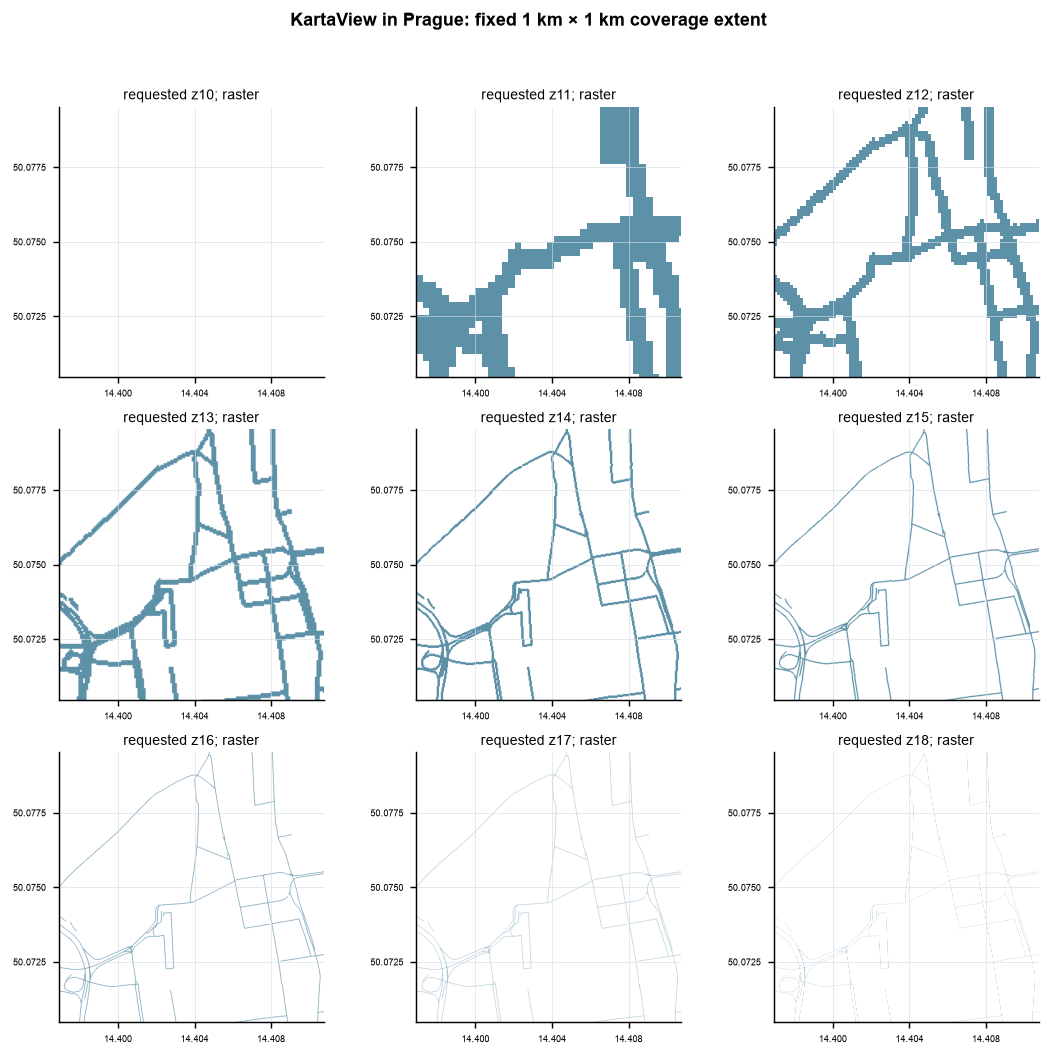

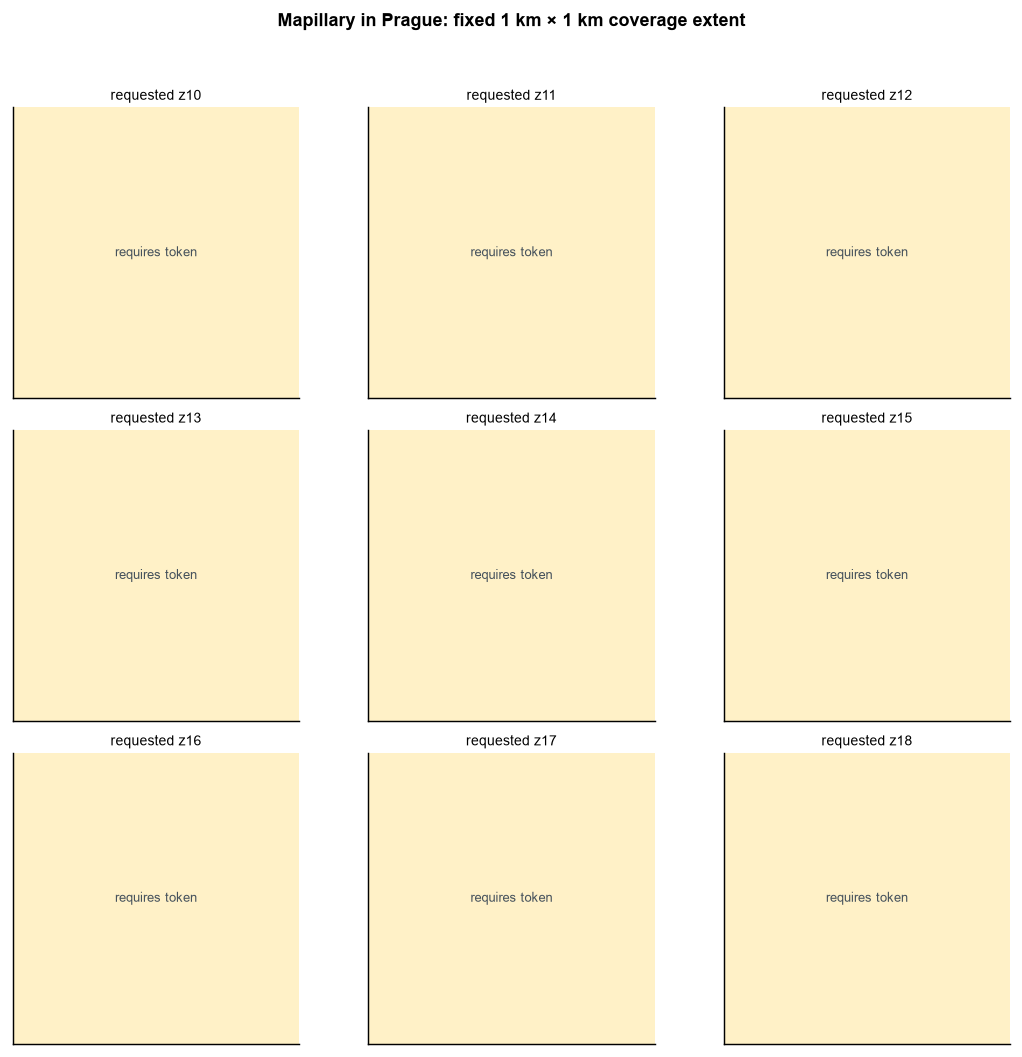

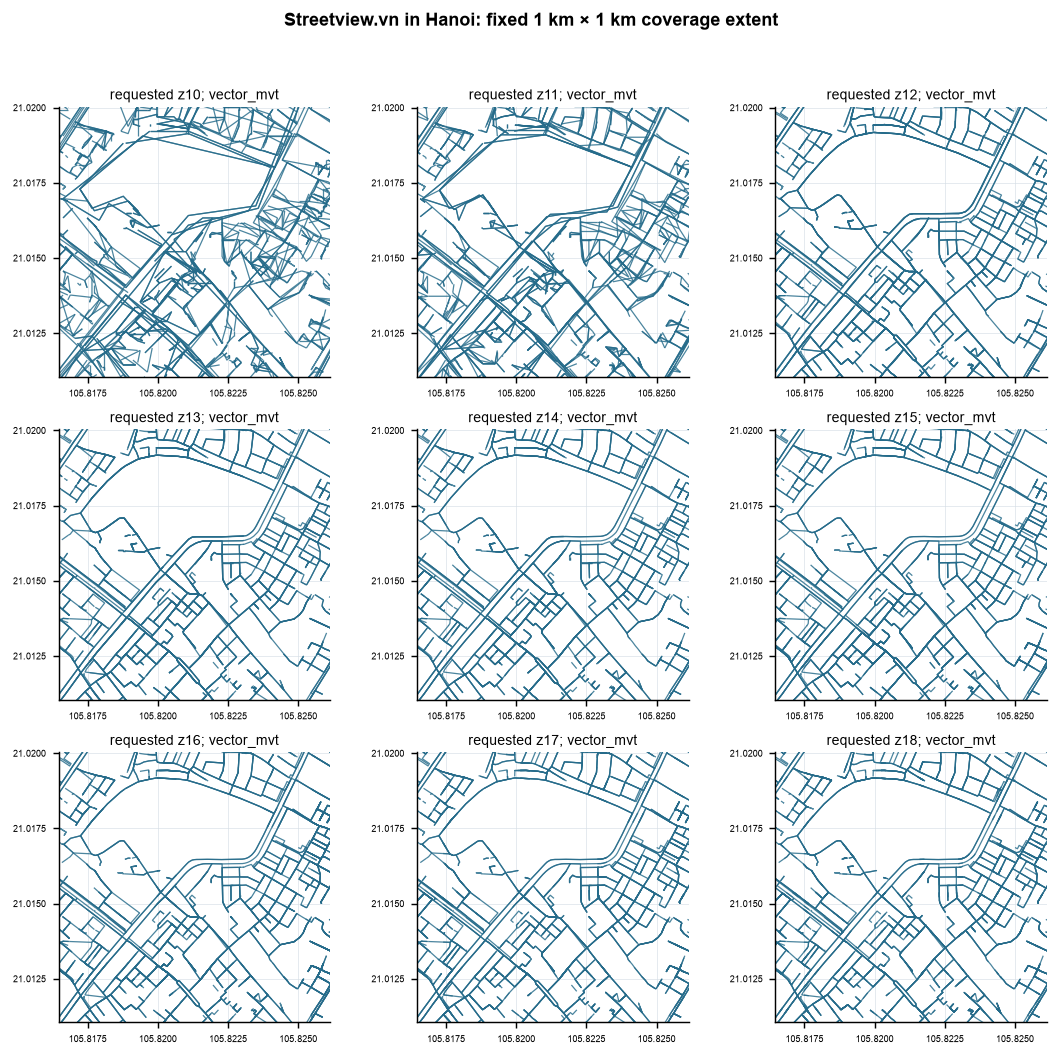

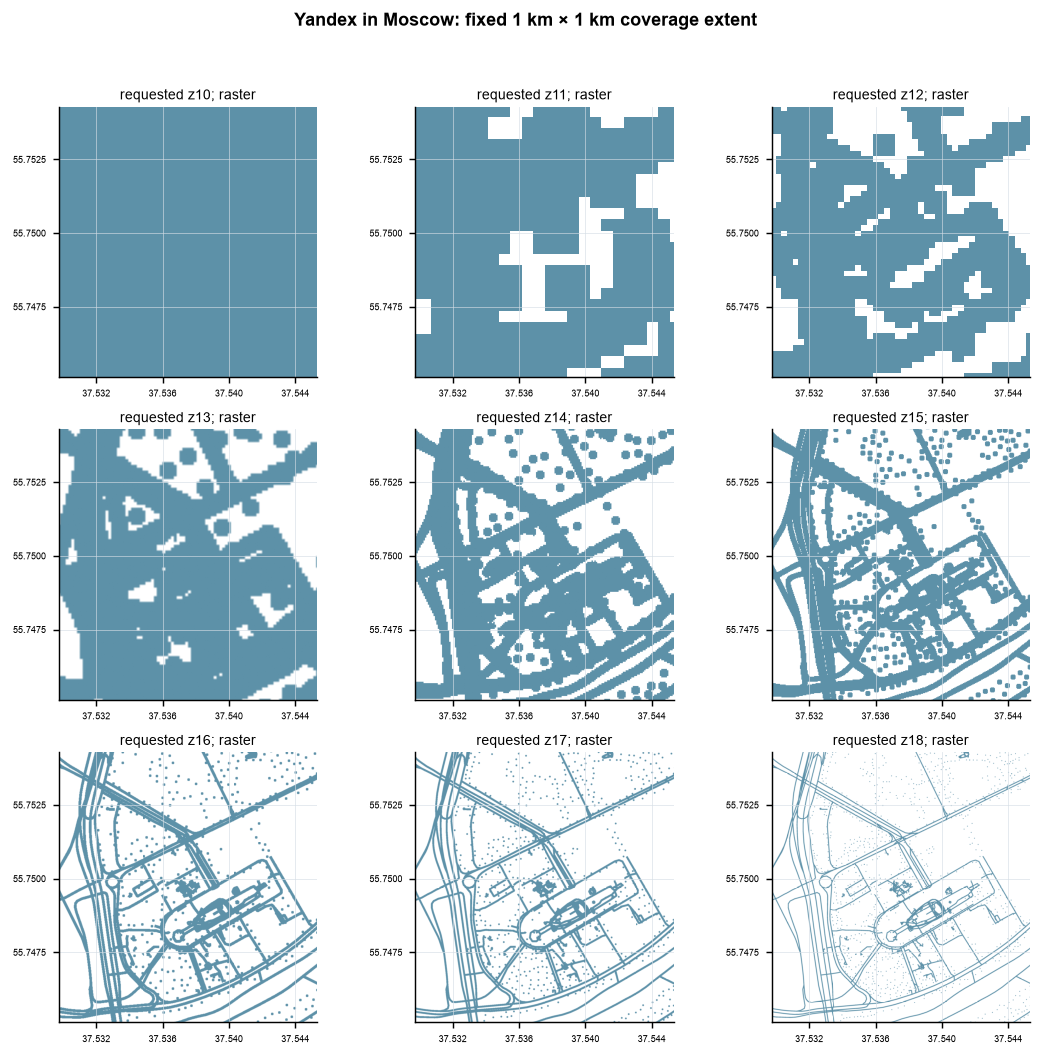

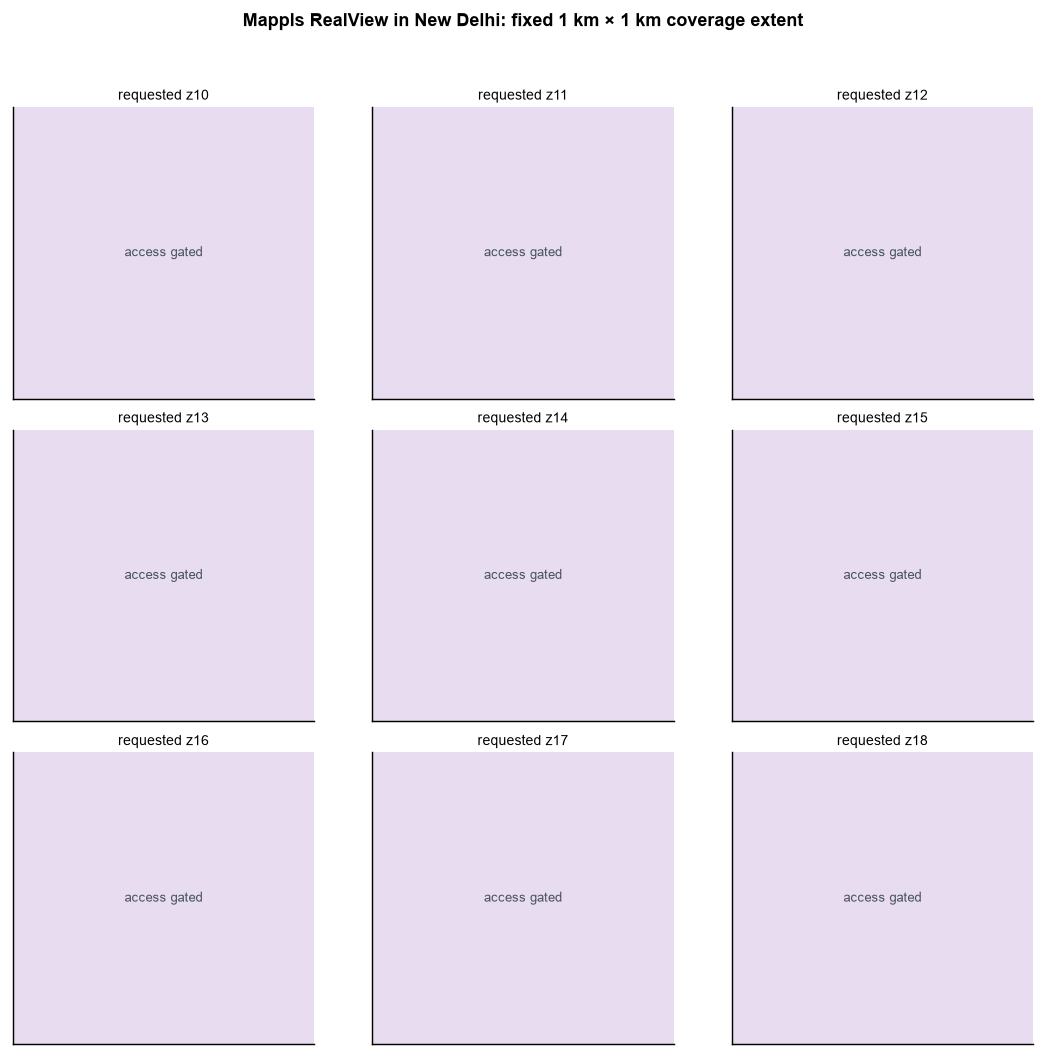

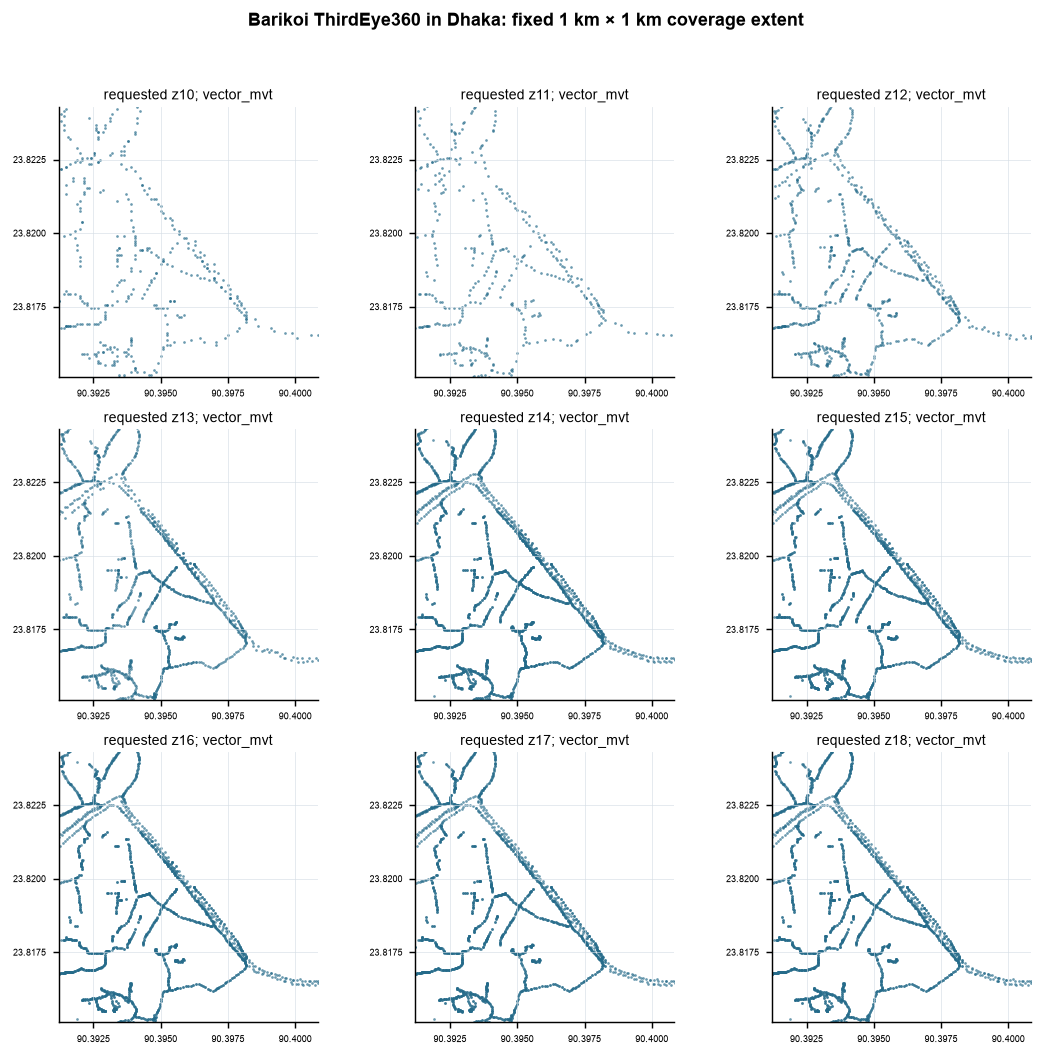

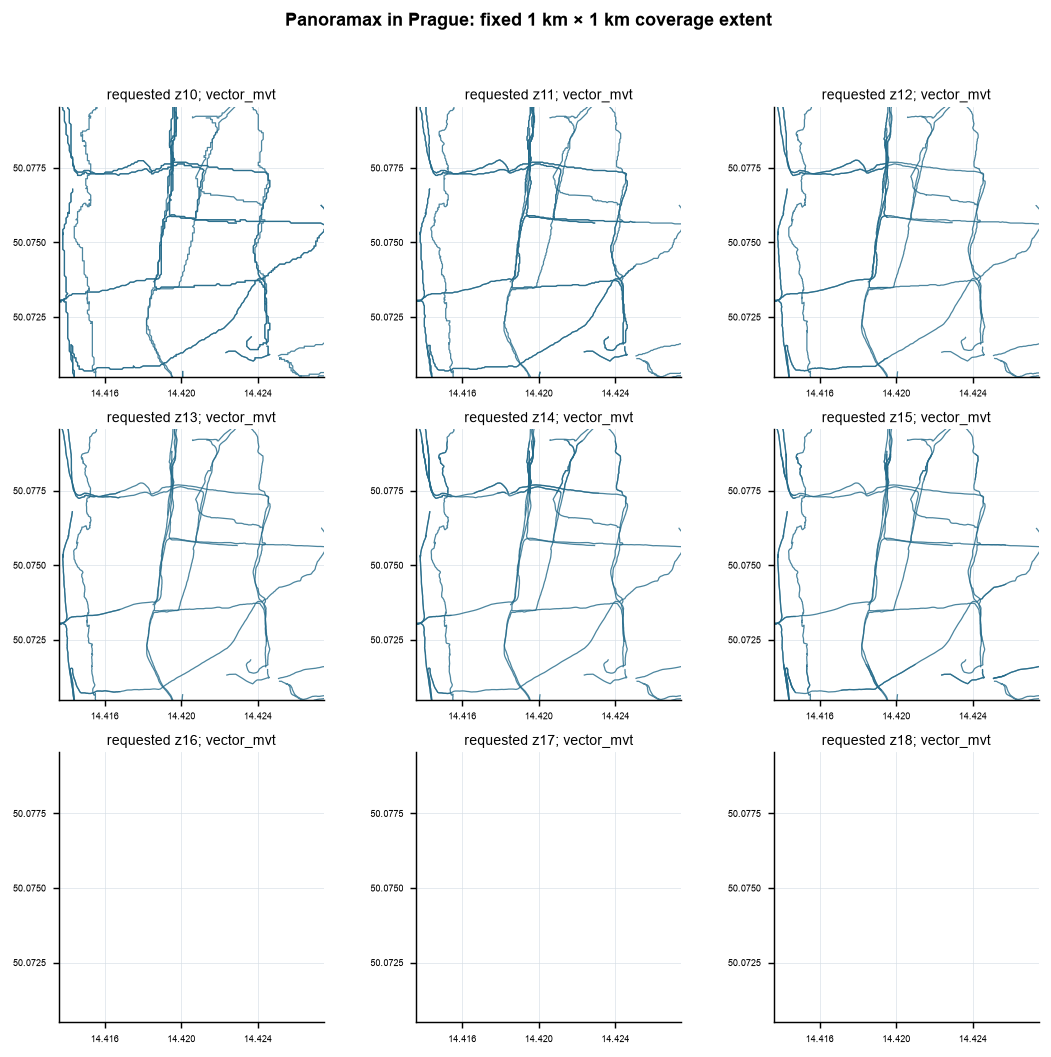

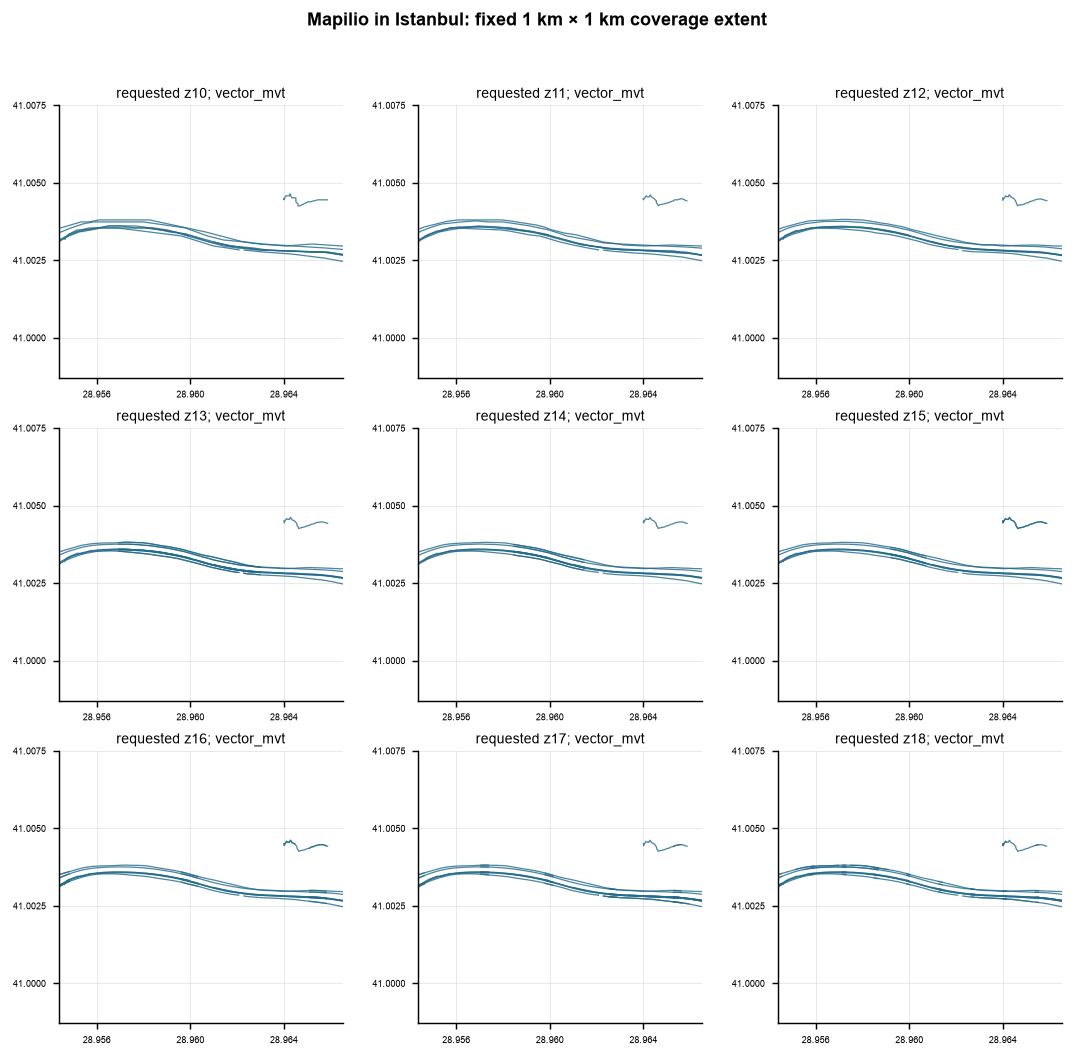

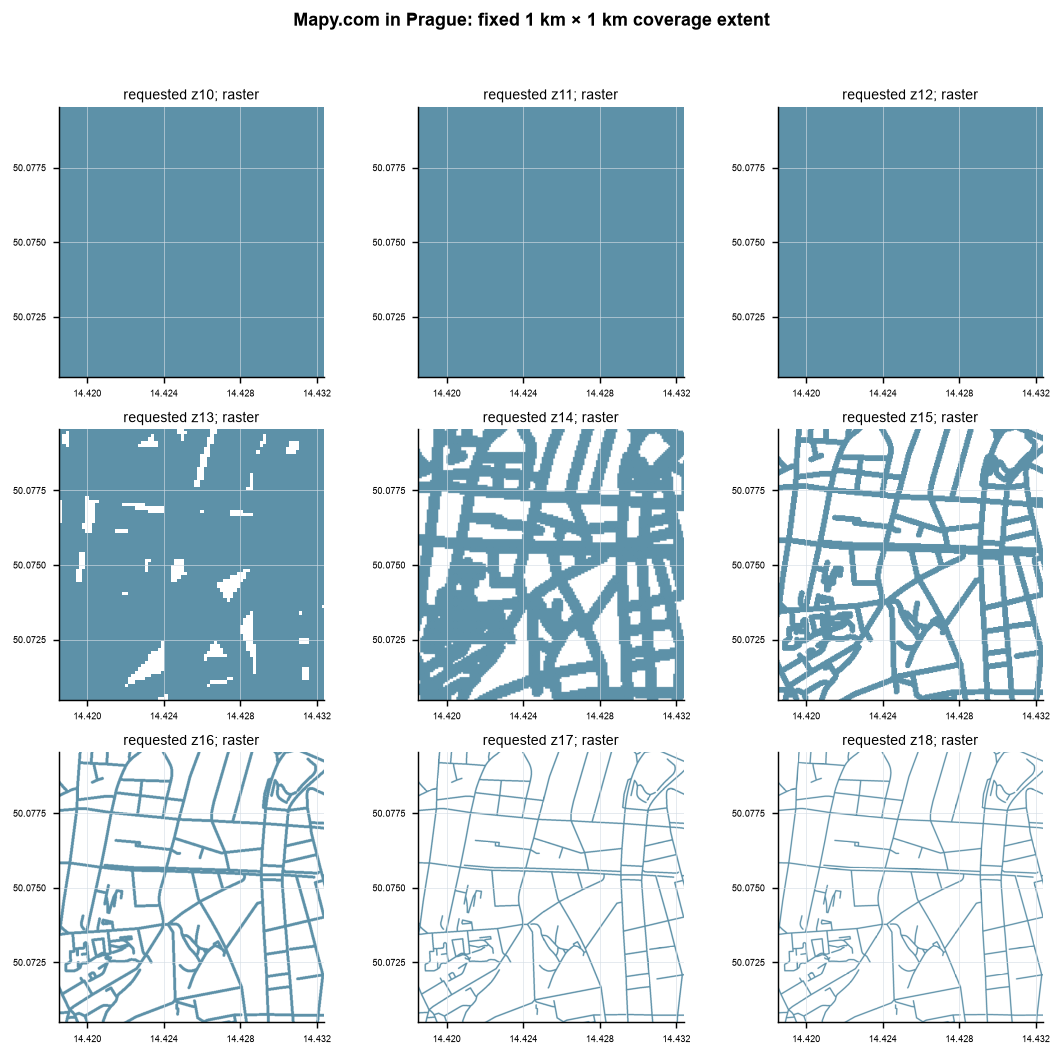

In [11]:
STATUS_COLORS = {
    "unsupported": "#E5E7EB",
    "access gated": "#E8DDF0",
    "requires token": "#FFF1C7",
    "not captured": "#EEF1F4",
    "fetch error": "#FBEAEA",
}


def status_panel(ax, bbox, title, status):
    style_geo_axis(ax, bbox, title, show_axis_labels=False)
    ax.set_facecolor(STATUS_COLORS[status])
    ax.text(0.5, 0.5, status, transform=ax.transAxes, ha="center", va="center", color="#46525C")
    ax.set_xticks([])
    ax.set_yticks([])


async def render_fixed_extent_provider(provider_key: str):
    case = multiscale_case(provider_key)
    bbox = fixed_extent_bboxes[provider_key]
    rows = zoom_plan_df.loc[zoom_plan_df["provider"].eq(provider_key)].set_index("requested_level")
    fig, axes = plt.subplots(3, 3, figsize=(8.4, 8.2), squeeze=False)
    for ax, requested_level in zip(axes.flat, MULTISCALE_LEVELS):
        row = rows.loc[requested_level]
        prefix = "L" if provider_key == "kakao" else "z"
        effective = row["effective_source_level"]
        effective_note = (
            "" if pd.isna(effective) or int(effective) == requested_level else f" → source z{int(effective)}"
        )
        level_label = f"requested {prefix}{requested_level}{effective_note}"
        if row["plan_status"] == "unsupported":
            status_panel(ax, bbox, level_label, "unsupported")
            continue
        if row["plan_status"] == "access_gated" and provider_key not in AUTHORIZED_ACCESS_GATED:
            status_panel(ax, bbox, level_label, "access gated")
            continue
        if row["plan_status"] == "requires_token" and not MAPILLARY_ACCESS_TOKEN:
            status_panel(ax, bbox, level_label, "requires token")
            continue
        if not CAPTURE_FIXED_EXTENT_MAPS:
            status_panel(ax, bbox, level_label, "not captured")
            continue

        acquisition = None
        try:
            acquisition = await acquire_fixed_extent(provider_key, requested_level)
            if acquisition["kind"] == "mappls":
                _returned_bbox, segments = load_mappls_segments(acquisition["result"]["run_summary"])
                plot_mappls_segments(
                    ax,
                    segments,
                    bbox=bbox,
                    label="",
                    level_label=level_label,
                    show_counts=False,
                )
            else:
                plot_result(
                    ax,
                    acquisition["result"],
                    bbox=bbox,
                    label="",
                    level_label=level_label,
                    max_plot_records=50_000,
                    show_axis_labels=False,
                    show_counts=False,
                )
        except Exception as exc:
            status_panel(ax, bbox, f"{level_label}\n{type(exc).__name__}", "fetch error")
        finally:
            if acquisition is not None:
                shutil.rmtree(Path(acquisition["cleanup_root"]), ignore_errors=False)

    fig.suptitle(
        f"{PROVIDER_LABELS[provider_key]} in {case.area}: fixed 1 km × 1 km coverage extent",
        fontsize=10,
        fontweight="bold",
    )
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    REFERENCE_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
    output_path = REFERENCE_FIGURE_ROOT / f"fixed_extent_{provider_key}.png"
    fig.savefig(output_path, dpi=130, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return output_path


if CAPTURE_FIXED_EXTENT_MAPS:
    if not ALLOW_NETWORK:
        raise RuntimeError("SVI_CAPTURE_FIXED_EXTENT_MAPS=1 also requires SVI_NOTEBOOK_ALLOW_NETWORK=1.")
    for provider_key in provider_order:
        if FIXED_EXTENT_PROVIDER_FILTER and provider_key not in FIXED_EXTENT_PROVIDER_FILTER:
            continue
        output_path = REFERENCE_FIGURE_ROOT / f"fixed_extent_{provider_key}.png"
        if FORCE_FIXED_EXTENT_REFRESH or not output_path.exists():
            await render_fixed_extent_provider(provider_key)

fixed_extent_reference_paths = [
    REFERENCE_FIGURE_ROOT / f"fixed_extent_{provider_key}.png" for provider_key in provider_order
]
available_fixed_extent_paths = [path for path in fixed_extent_reference_paths if path.exists()]
if SHOW_REFERENCE_MAPS and available_fixed_extent_paths:
    for path in available_fixed_extent_paths:
        display(NotebookImage(filename=str(path)))
else:
    print(f"Embedded fixed-extent plates staged for this execution: {len(available_fixed_extent_paths)}")

In [12]:
implemented = set(PROVIDERS) | {TENCENT_KEY, MAPPLS_KEY}
compared = set(case_df["provider_key"])
audited = set(zoom_plan_df["provider"])
assert implemented == compared == audited
assert len(area_plan_df) == len(case_df)
assert len(zoom_plan_df) == 16 * len(MULTISCALE_LEVELS)
assert not RUN_ACQUISITIONS
print(
    f"Validated {len(compared)} providers, {len(AREA_COMPARISON_CASES)} same-area cases, "
    f"and {len(zoom_plan_df)} fixed-extent provider-level combinations. "
    f"Reference maps displayed: {len(area_reference_paths) + len(available_fixed_extent_paths)}."
)

Validated 16 providers, 10 same-area cases, and 144 fixed-extent provider-level combinations. Reference maps displayed: 25.
